# Polar Plot Visualisation 

This notebook helps you generate **polar plots (rose plots)** of trajectory angles and end trajectory angles for Killifish, based on data exported in `.csv` format.

It combines code and ideas from:
- ✅ `Polar_Plot_Coordinates_M.py` → `rose_plot()` function reused (with simplification)
- ✅ `visualisation_d48.ipynb` and `visualisation_modular_d48_d77_led.ipynb` → inspired use of `uroa_control`, `day` fields, and `led` angles

For each CSV, it will generate a figure with 8 subplots (4 days × 2 groups: control and uroa).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import os

print("Current working directory:", os.getcwd())

Current working directory: /Users/teeshabasak/Desktop/killifish/polar_plots


In [3]:
data_folder = "data"
output_folder = "outputs"

# Create output folder if it doesn't exist (in current location)
os.makedirs(output_folder, exist_ok=True)

# Make sure data folder exists 
if not os.path.exists(data_folder):
    raise FileNotFoundError(f"Data folder not found: '{data_folder}' — please check the path.")

# List of CSV files to process
# *Change this according to data you want to process
csv_files = [
    "trajectory_angle_d48.csv",
    "trajectory_angle_d77.csv",
    "end_trajectory_angle_d48.csv",
    "end_trajectory_angle_d77.csv",
    "head_angle_d48.csv",
    "head_angle_d77.csv"
]

# Create full paths and check for missing files
csv_paths = []
for filename in csv_files:
    path = os.path.join(data_folder, filename)
    if os.path.exists(path):
        csv_paths.append(path)
    else:
        print(f"Missing file: {path}")

# Rose Plot Function (From Ari's code)


This function draws a polar histogram (rose plot), a circular bar chart showing how often angles occur, divided into bins (like a pie chart in different directions)


<u>Arguements:</u>
- ax: sets the axis of the plot
- angles: array-like (in radians)
- bins: number of bins around circle - default = 16
- density: if True, scales radius to reflect % of total (instead of raw count) 
    - useful to compare fish with different numbers of entries
- offset: can rotate entire plot (default = 0, no rotation)
- lab_unit: how you want to label the angles on the graph (degrees/radians)
- start_zero: if True - bins will start from 0 and go evenly around circle - only needed for special cases
- param_dict: placeholder that lets you pass in extra optional settings like color, transparency, etc

In [4]:
def rose_plot(ax, angles, bins=16, density=False, offset=0, lab_unit="degrees",
              start_zero=False, **param_dict):
    
    angles = (angles + np.pi) % (2 * np.pi) - np.pi  # Wrap between [-π, π) - converting to rad

    if start_zero:
        if bins % 2:
            bins += 1
        bins = np.linspace(-np.pi, np.pi, num=bins+1)

    #split graph into num of bins and counts how many data points per bin (count)
    #bin_egde = angles that mark start/end of each bin
    count, bin_edges = np.histogram(angles, bins=bins)
    widths = np.diff(bin_edges)

    #if density=True, adjusts bar height to reflect percentages, else, uses raw number of angles per slice
    if density:
        area = count / angles.size
        radius = np.sqrt(area / np.pi)
    else:
        radius = count

    #draw graph
    ax.bar(bin_edges[:-1], radius, zorder=1, align='edge', width=widths,
           edgecolor='C0', fill=True, linewidth=1.5, alpha=0.7) 
    ax.set_yticks(np.arange(1, 8))
    ax.set_yticklabels([str(i) for i in range(1, 8)])
    
    ax.set_theta_offset(offset) #rotate graph if needed

    #change axis labels to radians if required
    if lab_unit == "radians":
        ax.set_xticklabels(['$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$',
                            r'$\pi$', r'$5\pi/4$', r'$3\pi/2$', r'$7\pi/4$'])

# Function to Plot 8 Subplots for One CSV File


This function creates an 8-panel polar plot figure from a single CSV file.

<i> CSV file expected to have columns: name, uroa_control, day, led. </i>


In [9]:
def plot_polar_8_subplots(csv_path, output_folder="polar_figures"):
    
    print(f"Reading file: {csv_path}")
    df = pd.read_csv(csv_path)

    # Add group column: 'control' or 'uroa'
    df['group'] = df['uroa_control'].apply(lambda x: 'uroa' if x else 'control')

    # Convert LED angle to radians (assumed to be in degrees)
    df['angle_rad'] = np.deg2rad(df['led'])

    # Setup figure
    fig, axes = plt.subplots(2, 4, subplot_kw=dict(projection='polar'), figsize=(20, 10))
    fig.suptitle(f"Trajectory direction — {os.path.basename(csv_path)}", fontsize=16)

    # Plot 8 subplots: (4 days × 2 groups)
    for i, day in enumerate([1, 2, 3, 4]):
        for j, group in enumerate(['control', 'uroa']):
            ax = axes[j, i]
            subset = df[(df['day'] == day) & (df['group'] == group)]

            valid_angles = subset['angle_rad'].dropna() #remove any invalid/empty angles

            if valid_angles.empty:
                #If there's no data to plot, skips it 
                ax.set_title(f"Day {day} {group}\n(no data)")
                print(f"No usable angle data (all NaN) for Day {day} - {group}") 
                ax.set_xticks([])
                ax.set_yticks([])
                continue
            #draw rose plot with valid data
            rose_plot(ax, valid_angles)
            ax.set_title(f"Day {day} {group}", fontsize=10)
            ax.tick_params(labelsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for title

    # Save plot
    os.makedirs(output_folder, exist_ok=True)
    save_name = os.path.join(output_folder, f"{os.path.basename(csv_path).replace('.csv', '')}_polar.png")
    plt.tight_layout(rect=[0, 0, 1, 0.95], pad=2.0) 
    base_name = os.path.join(output_folder, f"{os.path.basename(csv_path).replace('.csv', '')}_polar")

    plt.savefig(base_name + ".png", dpi=300, bbox_inches='tight')
    plt.savefig(base_name + ".svg", format='svg', bbox_inches='tight')

    print(f"Saved figure to {base_name}.png and .svg\n")

    display(fig)
    plt.close(fig)


Loop Over All 6 Files and Generate Plots

Reading file: data/trajectory_angle_d48.csv
Saved figure to outputs/trajectory_angle_d48_polar.png and .svg



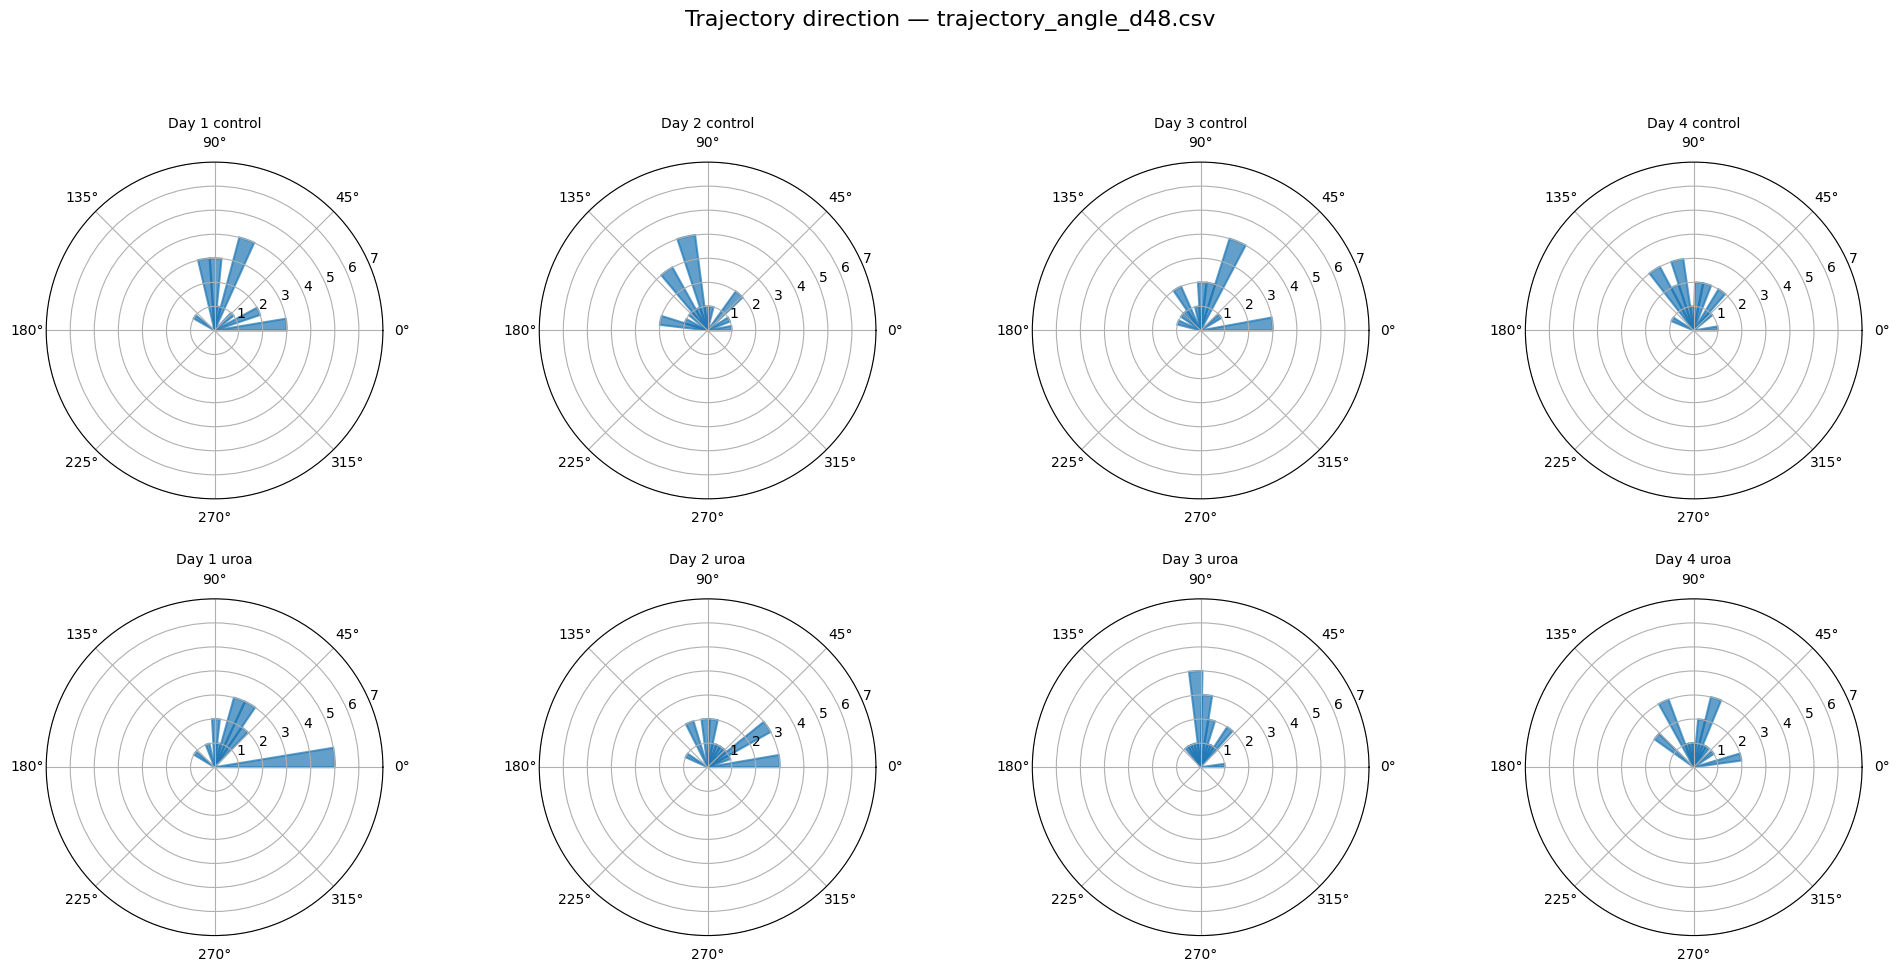

Reading file: data/trajectory_angle_d77.csv
Saved figure to outputs/trajectory_angle_d77_polar.png and .svg



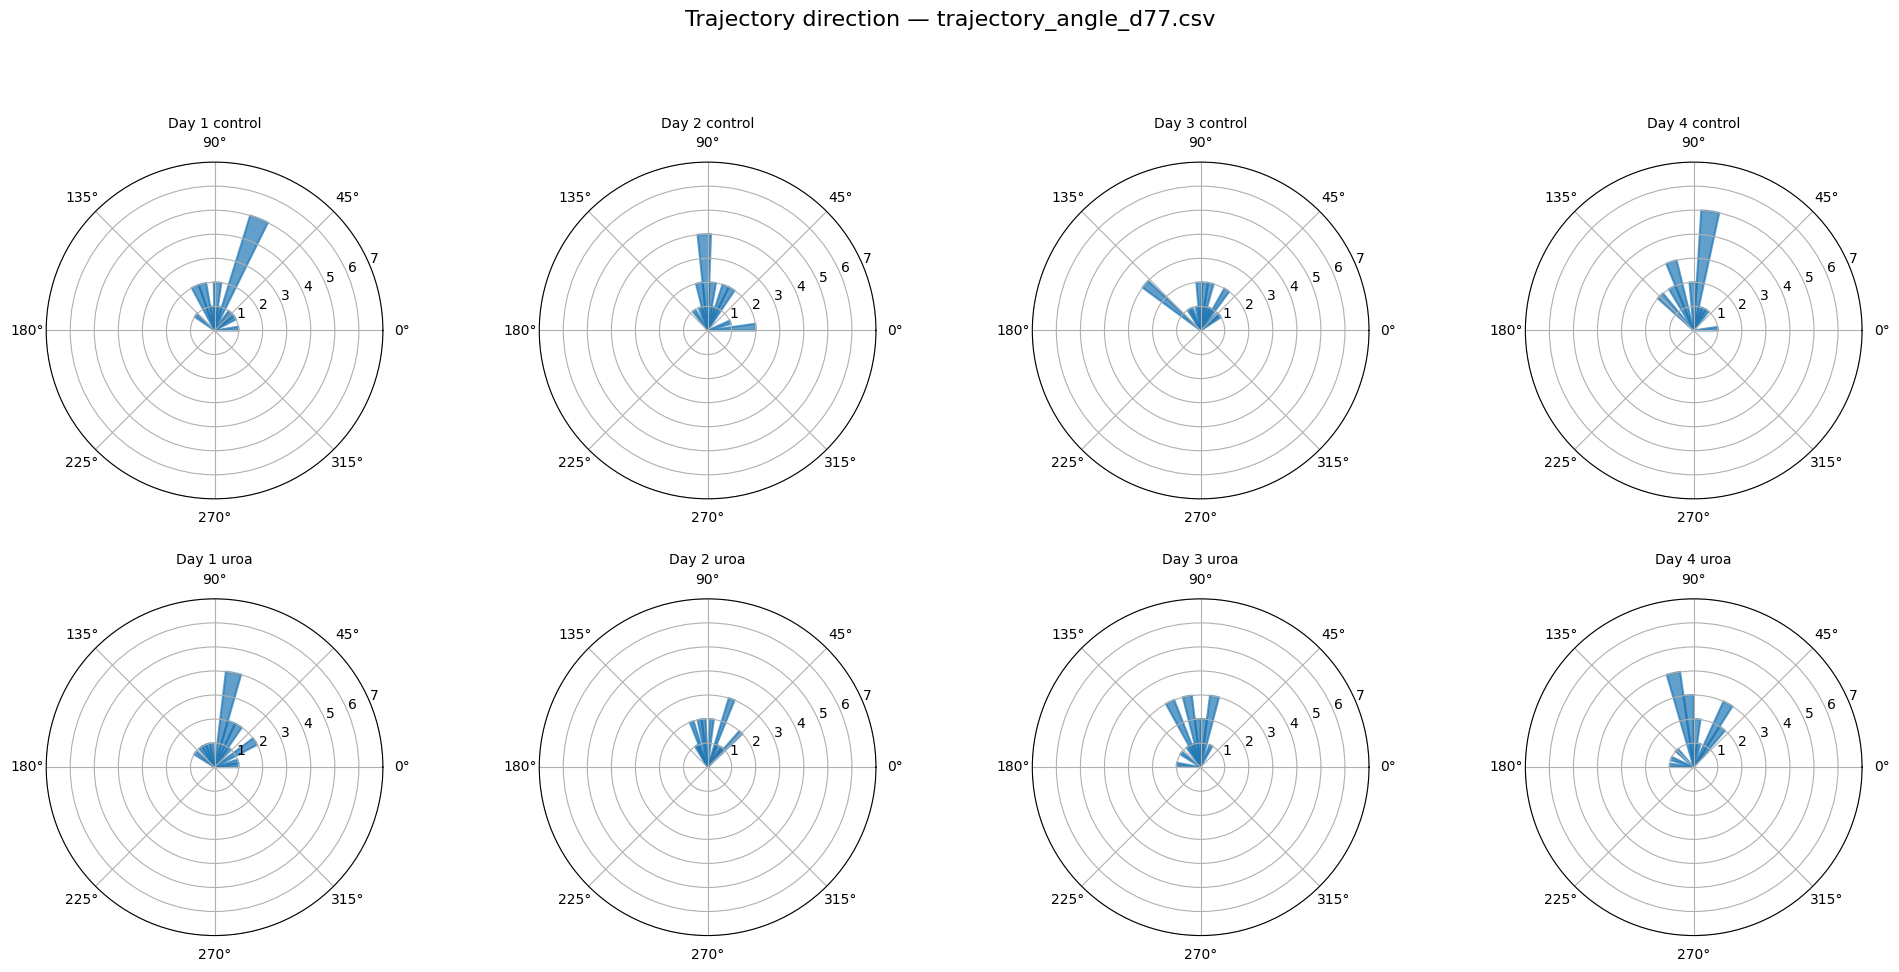

Reading file: data/end_trajectory_angle_d48.csv
Saved figure to outputs/end_trajectory_angle_d48_polar.png and .svg



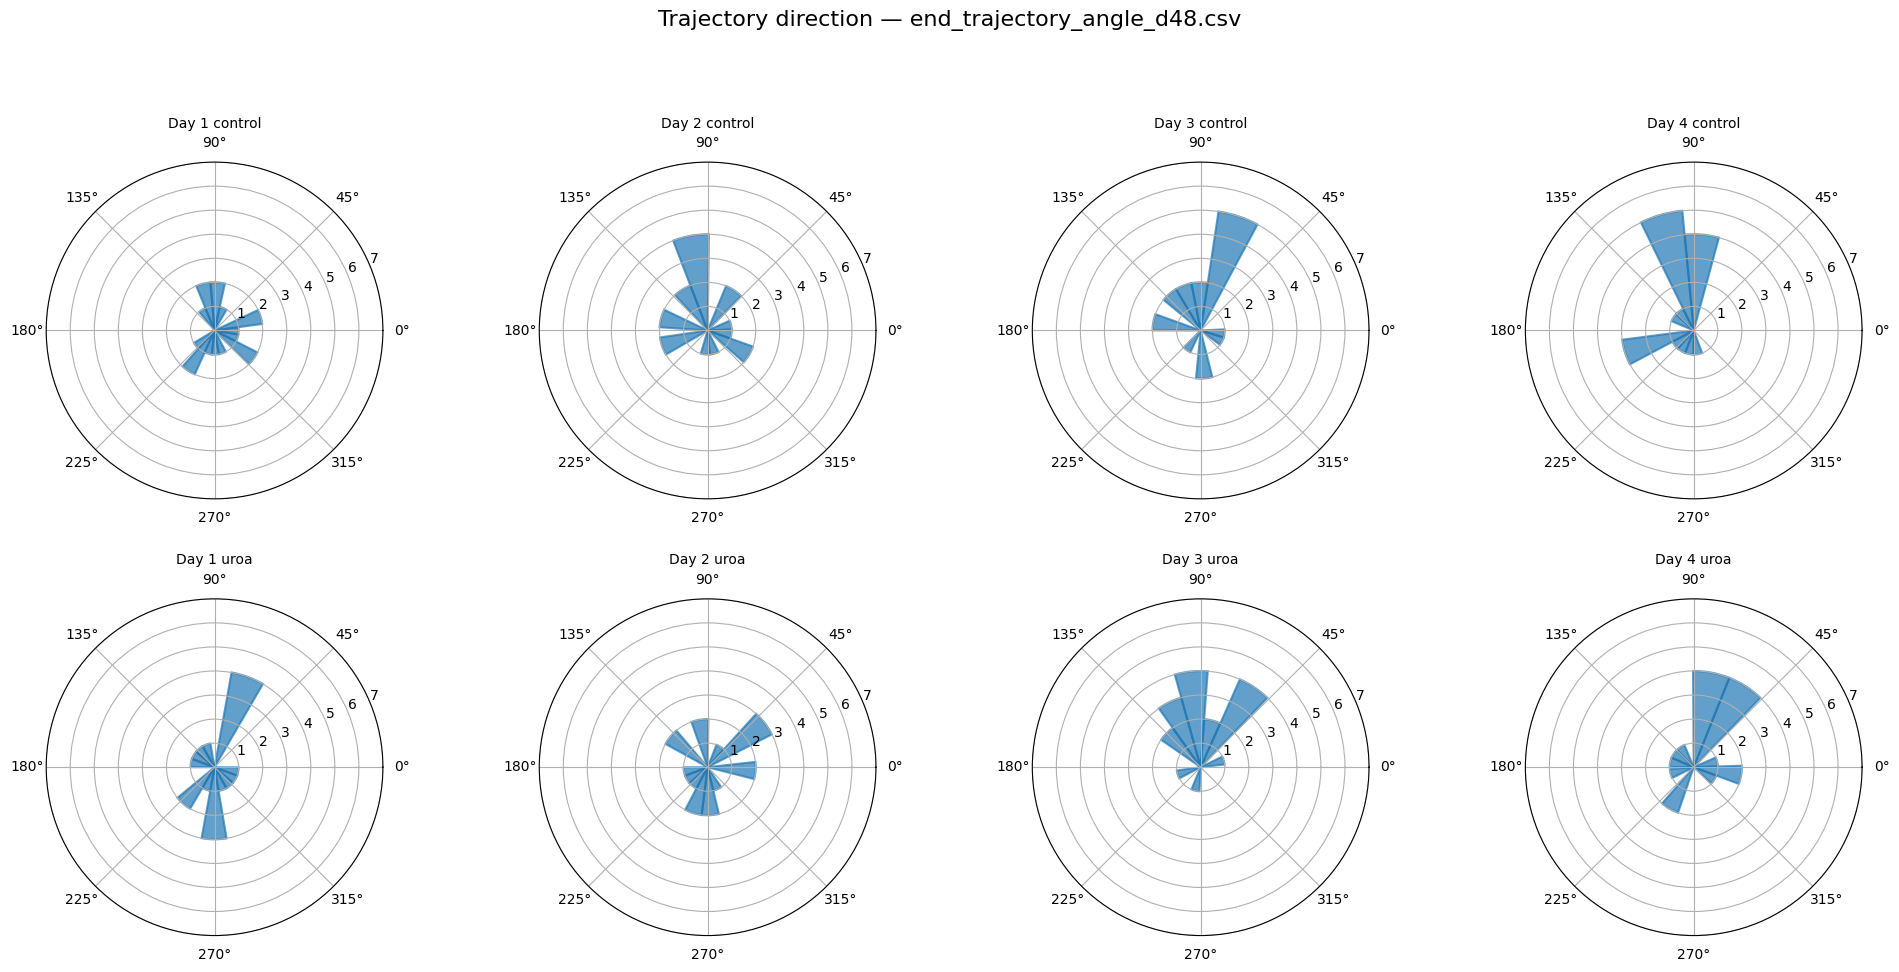

Reading file: data/end_trajectory_angle_d77.csv
Saved figure to outputs/end_trajectory_angle_d77_polar.png and .svg



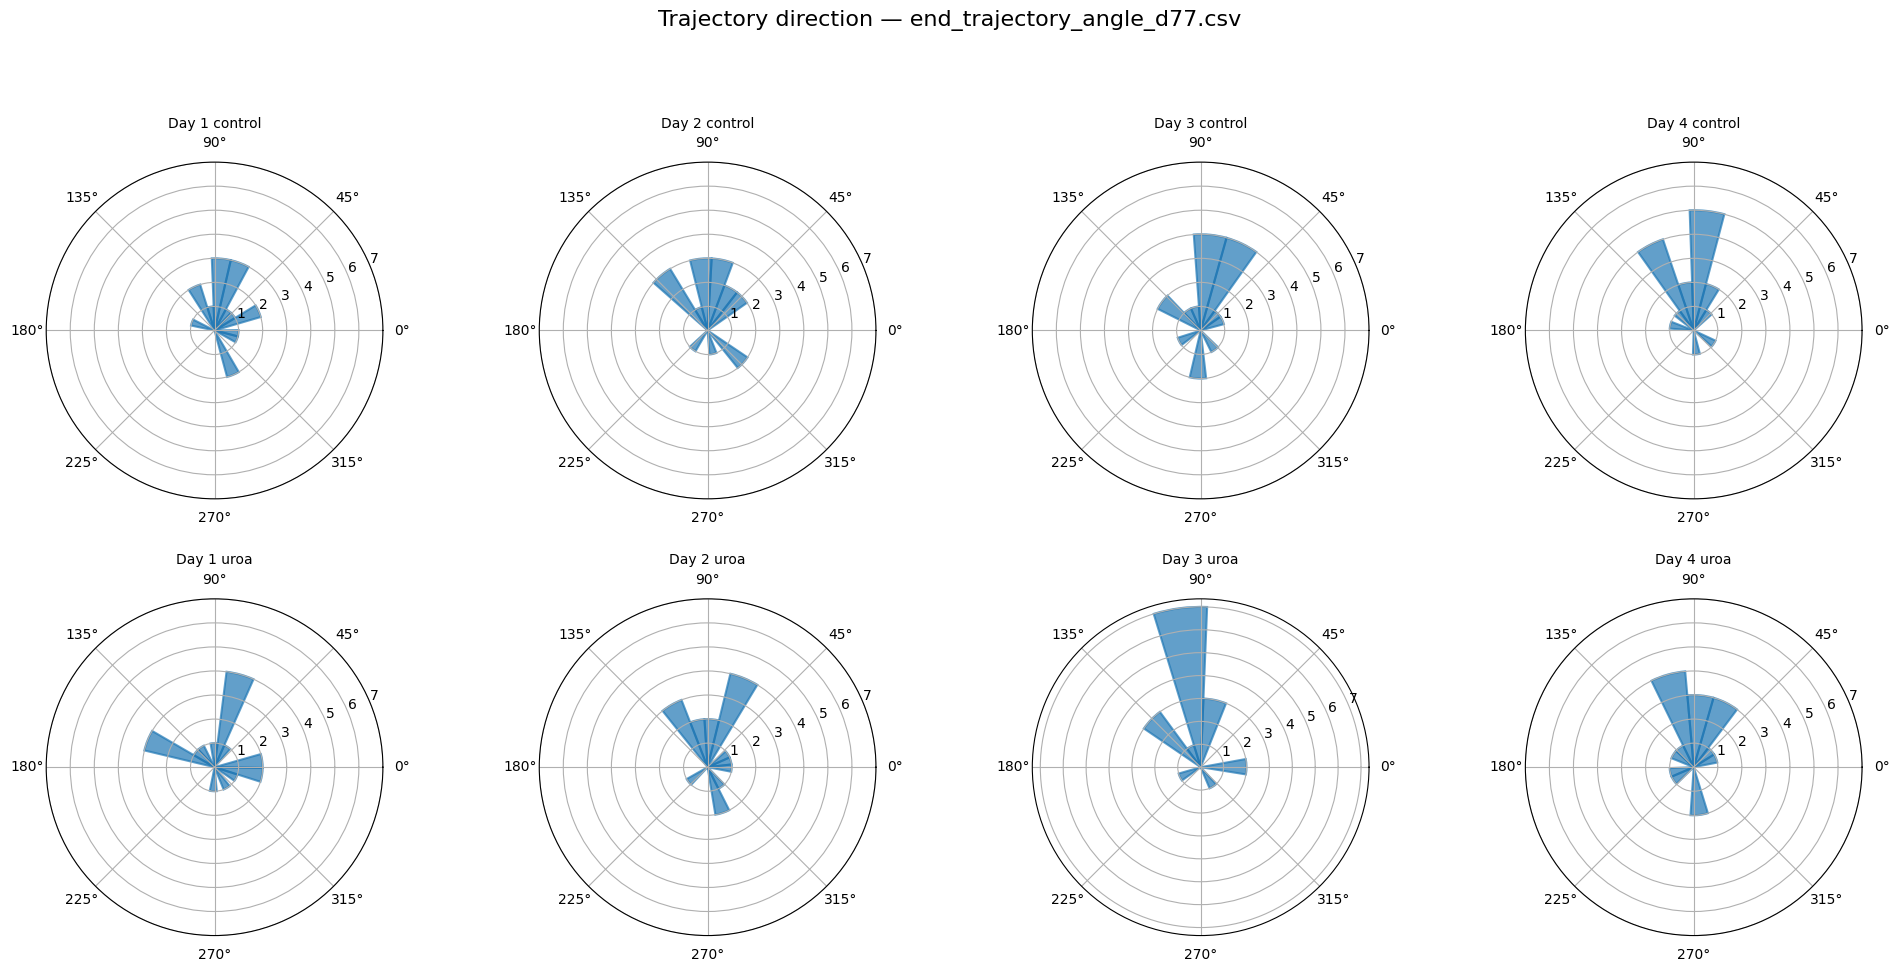

Reading file: data/head_angle_d48.csv
Saved figure to outputs/head_angle_d48_polar.png and .svg



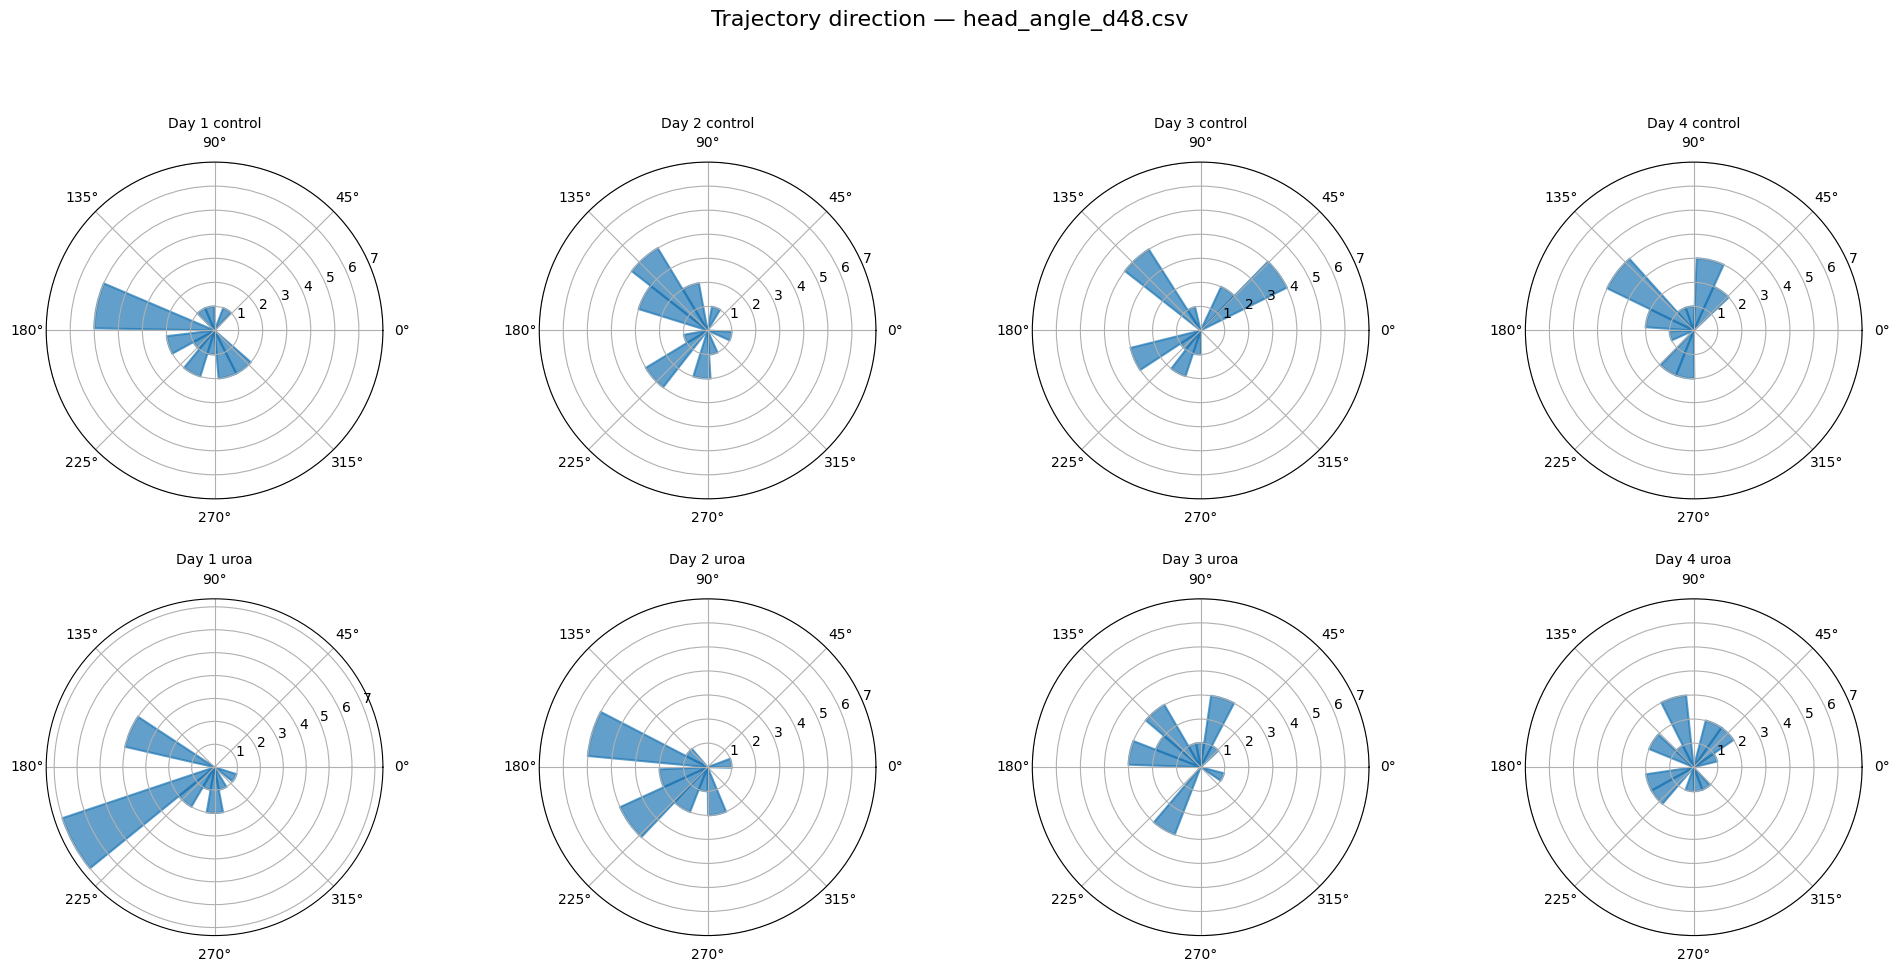

Reading file: data/head_angle_d77.csv
Saved figure to outputs/head_angle_d77_polar.png and .svg



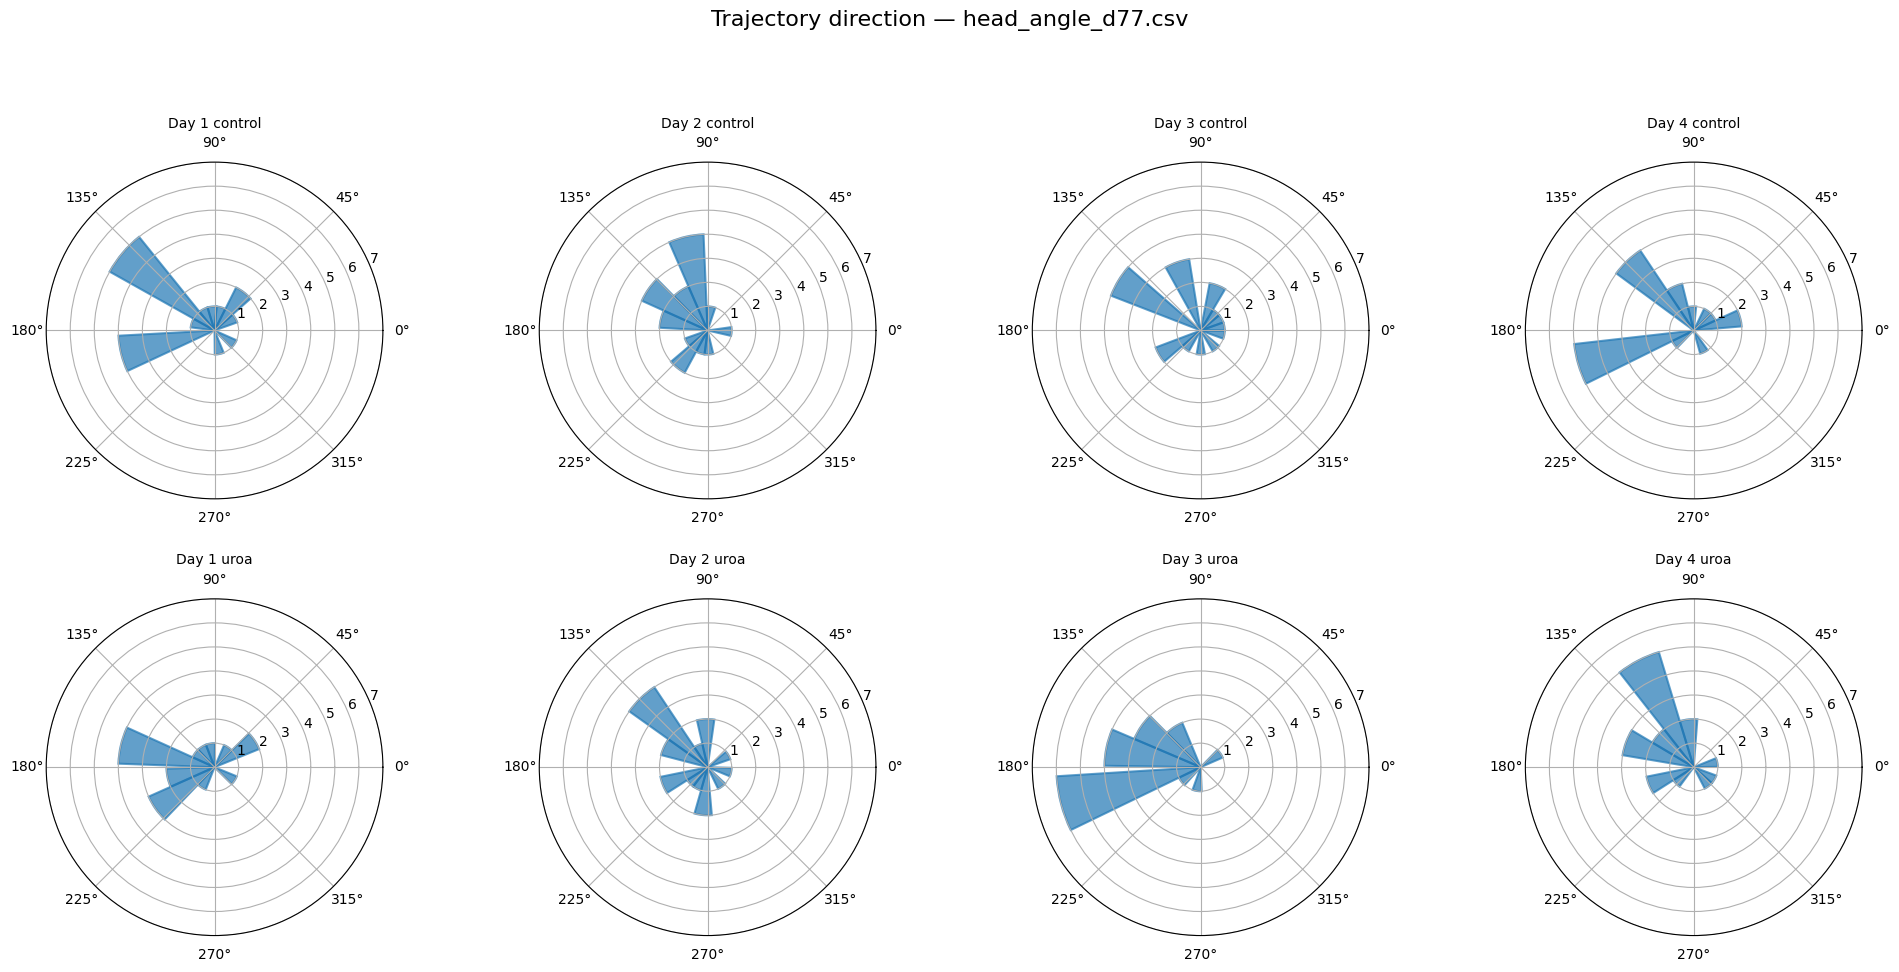

In [10]:
for file_path in csv_paths:
    plot_polar_8_subplots(file_path, output_folder)
